In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

df = df.drop(columns=['Unnamed: 0', 'id'])
df.columns = df.columns.str.replace(' ', '_').str.lower()

df.head()

,gender,customer_type,age,type_of_travel,class,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,...,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [129]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   gender                             103904 non-null  str    
 1   customer_type                      103904 non-null  str    
 2   age                                103904 non-null  int64  
 3   type_of_travel                     103904 non-null  str    
 4   class                              103904 non-null  str    
 5   flight_distance                    103904 non-null  int64  
 6   inflight_wifi_service              103904 non-null  int64  
 7   departure/arrival_time_convenient  103904 non-null  int64  
 8   ease_of_online_booking             103904 non-null  int64  
 9   gate_location                      103904 non-null  int64  
 10  food_and_drink                     103904 non-null  int64  
 11  online_boarding                    103904 non-null

In [130]:
# Missing values
df.isna().sum()

gender                                 0
customer_type                          0
age                                    0
type_of_travel                         0
class                                  0
flight_distance                        0
inflight_wifi_service                  0
departure/arrival_time_convenient      0
ease_of_online_booking                 0
gate_location                          0
food_and_drink                         0
online_boarding                        0
seat_comfort                           0
inflight_entertainment                 0
on-board_service                       0
leg_room_service                       0
baggage_handling                       0
checkin_service                        0
inflight_service                       0
cleanliness                            0
departure_delay_in_minutes             0
arrival_delay_in_minutes             310
satisfaction                           0
dtype: int64

In [131]:
df.describe()

,age,flight_distance,inflight_wifi_service,departure/arrival_time_convenient,ease_of_online_booking,gate_location,food_and_drink,online_boarding,seat_comfort,inflight_entertainment,on-board_service,leg_room_service,baggage_handling,checkin_service,inflight_service,cleanliness,departure_delay_in_minutes,arrival_delay_in_minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [132]:
# Cleaning the arrival_delay_in_minutes  column
df['arrival_delay_in_minutes'] = df['arrival_delay_in_minutes'].fillna(df['arrival_delay_in_minutes'].median())

##  Q1: Are people satisfied or not?

Text(0, 0.5, 'Count')

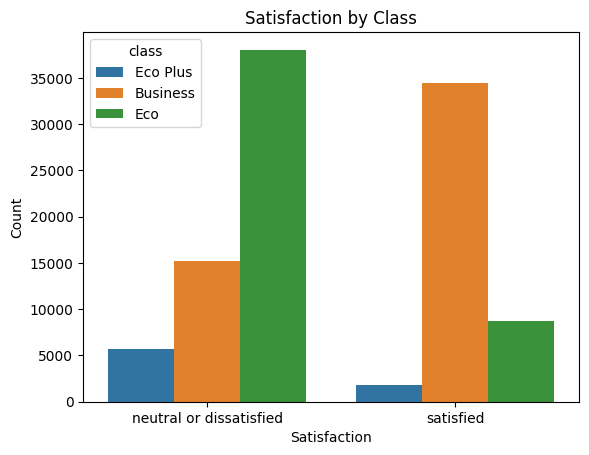

In [ ]:
sns.countplot(data=df, x='satisfaction', hue='class')
plt.title('Satisfaction by Class')
plt.xlabel('Satisfaction')
plt.ylabel('Count')

# Business class has the highest satisfaction rate at 69%, 
# compared to only 19% in Eco and 25% in Eco Plus.
# Class is one of the strongest predictors of satisfaction.

Text(0, 0.5, 'Percentage')

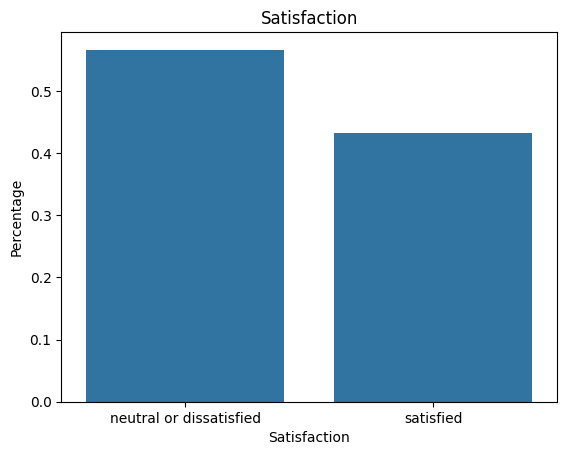

In [153]:
# sns.countplot(data=df, x='satisfaction')
# plt.title('Satisfaction')
# plt.xlabel('Satisfaction')
# plt.ylabel('Count')

perc = df['satisfaction'].value_counts(normalize=True).reset_index()
perc.columns = ['satisfaction', 'percent']

sns.barplot(data=perc, x='satisfaction', y='percent')
plt.title('Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Percentage')

##  Q2: Which class do male and female passengers fly most?

Text(0, 0.5, 'Count')

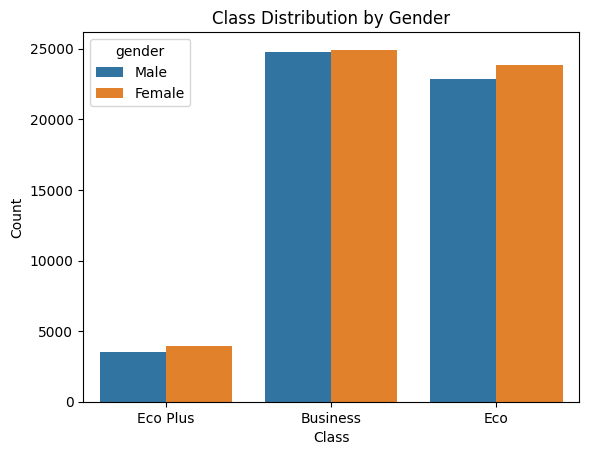

In [ ]:
sns.countplot(data=df, x='class', hue='gender')
plt.title('Class Distribution by Gender')
plt.xlabel('Class')
plt.ylabel('Count')
# Male and female passengers are split almost 50/50 across all classes,
# meaning gender is not a useful factor when targeting passengers by class.
# Marketing campaigns should focus on other factors like travel type

##  Q3: What percentage of passengers are Loyal Customers?

In [ ]:
per = df['customer_type'].value_counts(normalize=True) * 100
per
# 81% of passengers are loyal customers, yet 57% are still dissatisfied.
# This is a red flag — even our most committed customers are unhappy,
# meaning the dissatisfaction is not coming from one-time or new passengers.

customer_type
Loyal Customer       81.732176
disloyal Customer    18.267824
Name: proportion, dtype: float64

##  Q4: Do business travelers tend to be more satisfied?

Text(0, 0.5, 'Count')

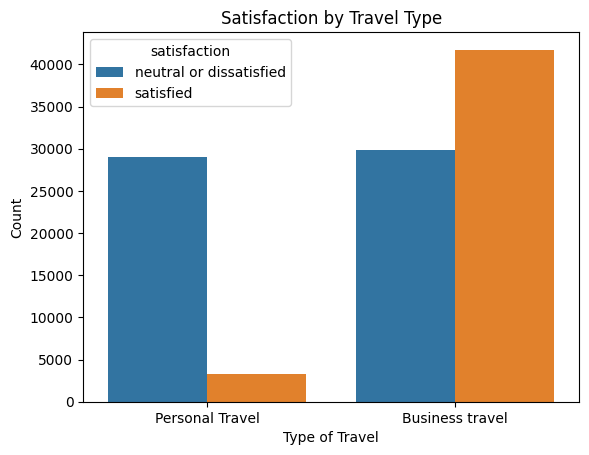

In [ ]:
sns.countplot(data=df, x='type_of_travel', hue='satisfaction')
plt.title('Satisfaction by Travel Type')
plt.xlabel('Type of Travel')
plt.ylabel('Count')

# Business travelers are far more satisfied than personal travelers 
# Personal travel passengers are almost always dissatisfied or neutral
# This suggests the airline experience is designed for business travelers not leisure ones.

##  Q5: Which service has the lowest average rating?

Text(0.5, 0, 'Average Rating')

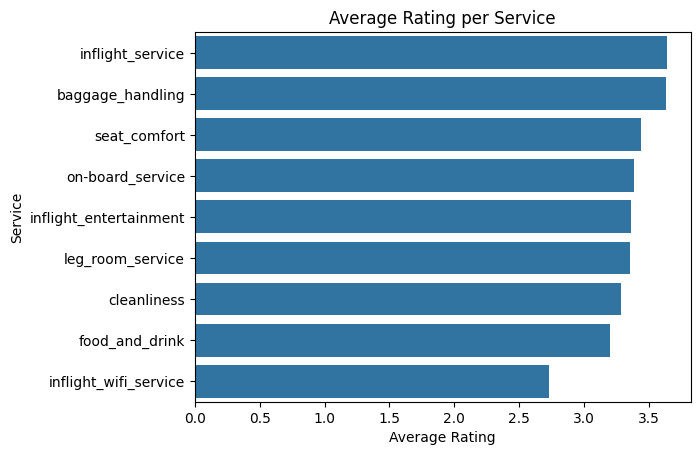

In [ ]:
col = [
    'inflight_wifi_service', 'food_and_drink', 'cleanliness',
    'leg_room_service', 'inflight_entertainment', 'on-board_service',
    'seat_comfort', 'baggage_handling', 'inflight_service'
]

x = df[col].mean().sort_values(ascending=False).reset_index()
x.columns = ['Service', 'Average Rating']

sns.barplot(data=x, x='Average Rating', y='Service')
plt.title('Average Rating per Service')
plt.xlabel('Average Rating')
# Inflight wifi has the lowest rating significantly below every other service.
# Improving wifi quality could have a direct impact on overall passenger satisfaction.

##  Q6: Correlation between services and flight distance

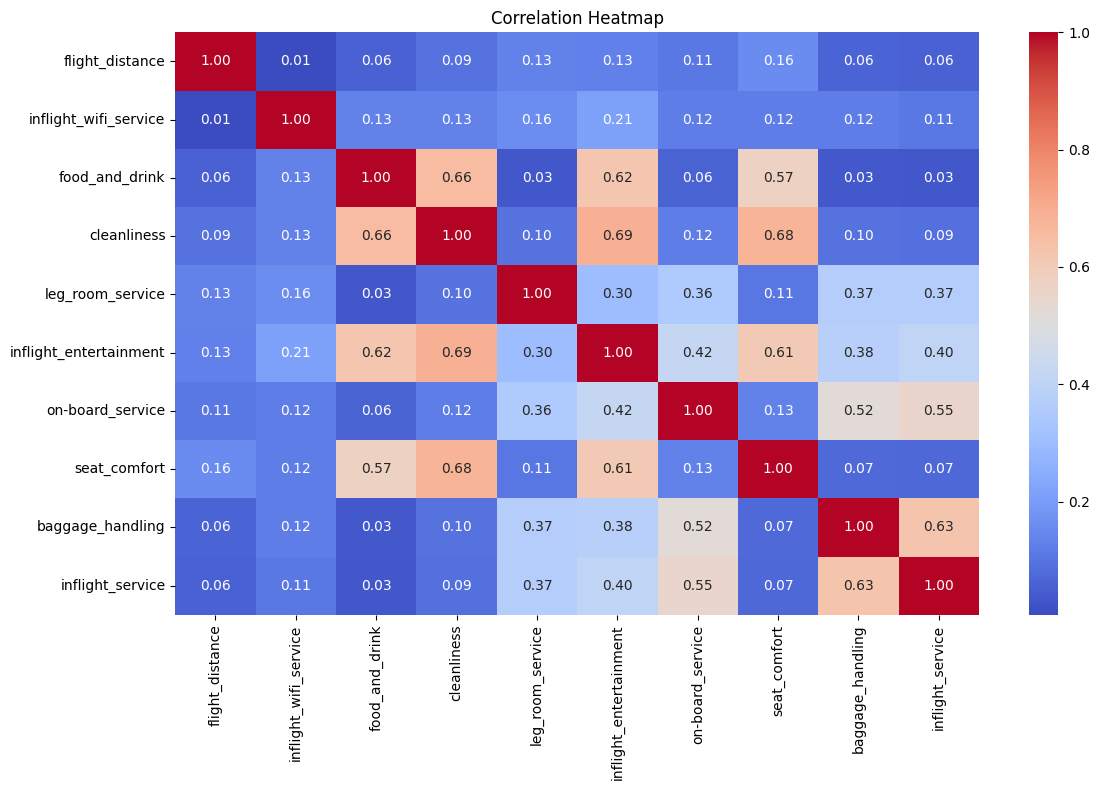

In [138]:
col2 = ['flight_distance'] + col

plt.figure(figsize=(12, 8))
sns.heatmap(df[col2].corr(), annot=True, fmt='.2f' ,cmap='coolwarm' )
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

##  Q7: Do delays actually impact satisfaction? **

Text(0, 0.5, 'Departure Delay')

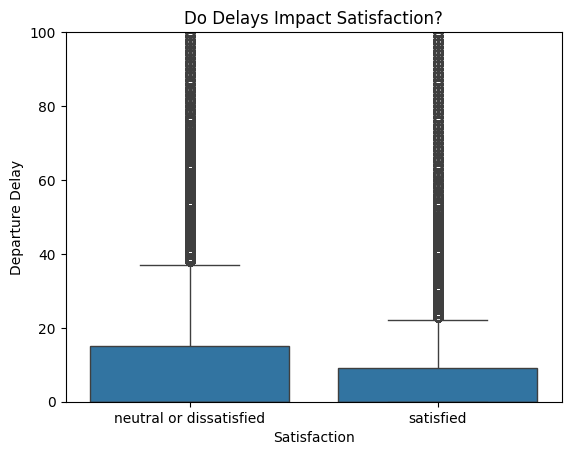

In [139]:
sns.boxplot(data=df, x='satisfaction', y='departure_delay_in_minutes')
plt.ylim(0, 100)
plt.title('Do Delays Impact Satisfaction?')
plt.xlabel('Satisfaction')
plt.ylabel('Departure Delay')
# Interestingly, delays alone don't seem to strongly separate satisfied from dissatisfied passengers

## Q8: Average age of satisfied vs dissatisfied passengers


Text(0.5, 1.0, 'Avg Age for Stisfaied Passengers')

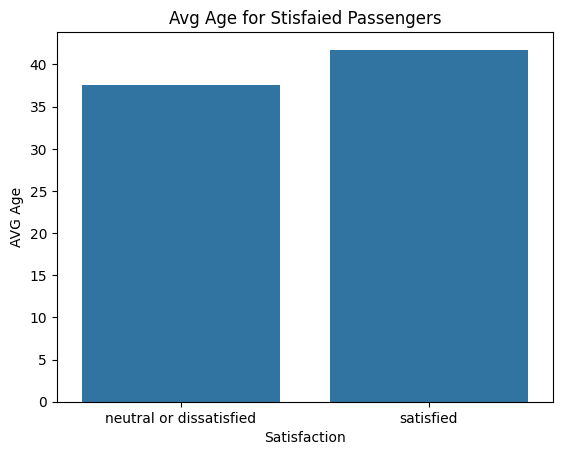

In [140]:
age_satisf = df.groupby('satisfaction')['age'].mean().reset_index()
sns.barplot(data = age_satisf , x = 'satisfaction' , y = 'age')
plt.xlabel("Satisfaction")
plt.ylabel("AVG Age")
plt.title("Avg Age for Stisfaied Passengers")
# This is my solution but i saw some code on Kaggle i saw someone use histogram so i will do it in the next cell

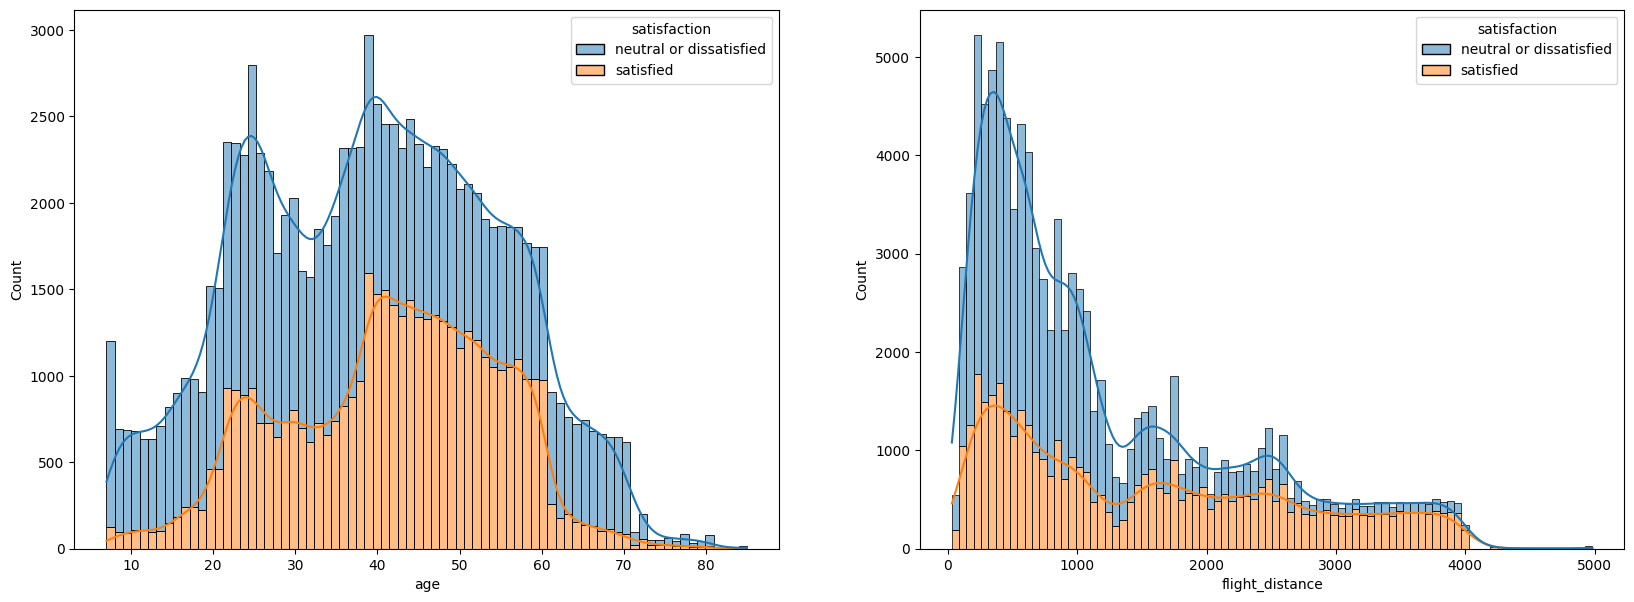

In [ ]:
colm = ['age', 'flight_distance']
fig, ax = plt.subplots(1,2, figsize= (20,7))

for i, col in enumerate(colm):
    sns.histplot(data=df, x=col, hue='satisfaction', multiple='stack', kde=True, ax=ax[i])
# I got a little more excited :)

# Young passengers (10-30) are mostly dissatisfied while middle-aged (35-60) are more satisfied.
# This connects to flight distance — middle-aged passengers tend to take longer flights
# which are mostly business class, explaining both the age and distance patterns.
# In short: age, distance, and class are all linked together and all point to the same story —
# business travelers are the happy ones.

## Q9: Which class has the highest satisfaction rate 

Text(0.5, 1.0, 'Highest Satisfaction Rate across Class')

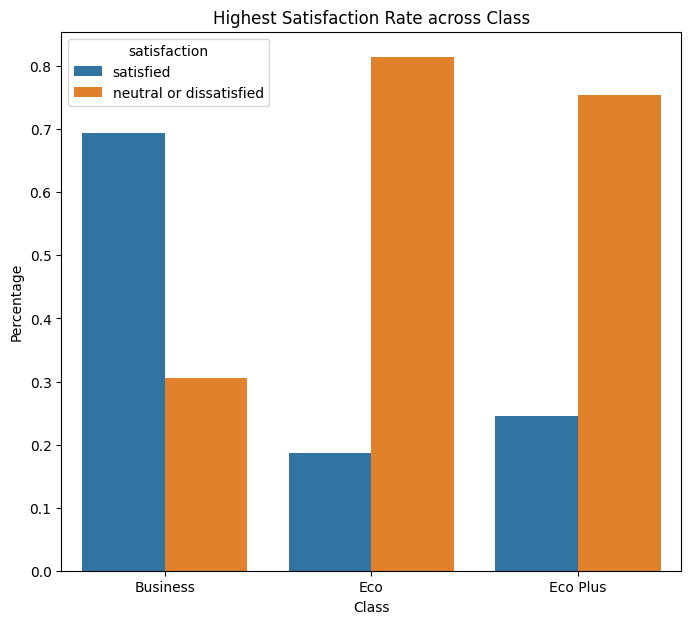

In [158]:
class_sat_rate = df.groupby("class")['satisfaction'].value_counts(normalize=True).reset_index()
plt.figure(figsize=(8, 7))
sns.barplot(data = class_sat_rate , y = 'proportion' , x = 'class' , hue = 'satisfaction')
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.title("Highest Satisfaction Rate across Class")

## Q10:  What factors are most correlated with satisfaction ** 



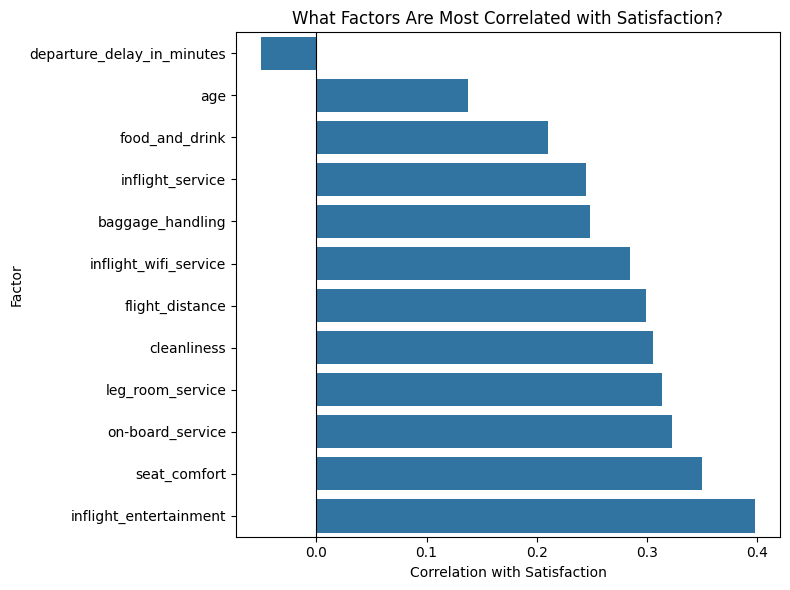

In [ ]:
# Step 1: convert satisfaction to numbers
df['satisfaction_num'] = df['satisfaction'].map({'satisfied': 1, 'neutral or dissatisfied': 0})

# Step 2: get correlation with satisfaction only
service_cols = [
    'inflight_wifi_service', 'food_and_drink', 'cleanliness',
    'leg_room_service', 'inflight_entertainment', 'on-board_service',
    'seat_comfort', 'baggage_handling', 'inflight_service',
    'flight_distance', 'age', 'departure_delay_in_minutes'
]

corr = df[service_cols + ['satisfaction_num']].corr()[['satisfaction_num']].drop('satisfaction_num')
corr = corr.sort_values('satisfaction_num')

# Step 3: plot
plt.figure(figsize=(8, 6))
sns.barplot(data=corr.reset_index(), x='satisfaction_num', y='index')
plt.xlabel('Correlation with Satisfaction')
plt.ylabel('Factor')
plt.title('What Factors Are Most Correlated with Satisfaction?')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Inflight entertainment is the strongest driver of satisfaction (0.40),
# followed closely by seat comfort (0.35) and on-board service (0.32).
# Departure delay is the only negative factor but at -0.05 it's nearly zero,
# meaning delays barely affect how passengers feel.
# The airline should invest in entertainment and comfort, not obsess over delays.